In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ")

All libraries loaded ✅


In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [3]:
# Amount and Time need scaling — V1-V28 already PCA transformed
scaler = StandardScaler()

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

print("Amount and Time scaled")
print(f"Amount_Scaled — Mean: {df['Amount_Scaled'].mean():.4f}, Std: {df['Amount_Scaled'].std():.4f}")
print(f"Time_Scaled   — Mean: {df['Time_Scaled'].mean():.4f}, Std: {df['Time_Scaled'].std():.4f}")

Amount and Time scaled
Amount_Scaled — Mean: -0.0000, Std: 1.0000
Time_Scaled   — Mean: -0.0000, Std: 1.0000


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # maintains fraud ratio in both splits
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Train size: (227845, 30)
Test size:  (56962, 30)

Train class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


Before SMOTE:
  Normal: 227,451
  Fraud:  394
  Ratio:  577:1

After SMOTE:
  Normal: 227,451
  Fraud:  227,451
  Ratio:  1:1 


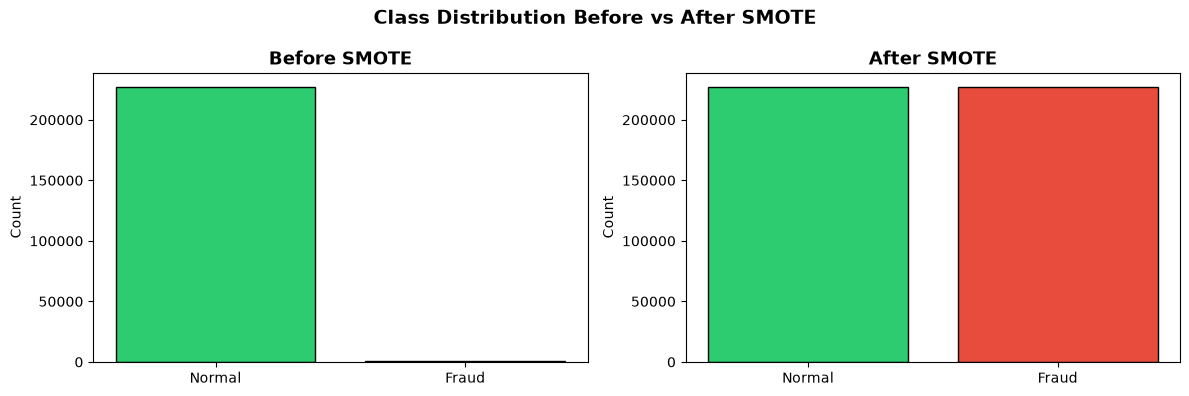

In [5]:
print("Before SMOTE:")
print(f"  Normal: {sum(y_train==0):,}")
print(f"  Fraud:  {sum(y_train==1):,}")
print(f"  Ratio:  {sum(y_train==0)//sum(y_train==1)}:1")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Normal: {sum(y_train_smote==0):,}")
print(f"  Fraud:  {sum(y_train_smote==1):,}")
print(f"  Ratio:  1:1 ")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal', 'Fraud'], 
            [sum(y_train==0), sum(y_train==1)],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(['Normal', 'Fraud'],
            [sum(y_train_smote==0), sum(y_train_smote==1)],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Check correlation of features with target
correlations = pd.DataFrame(X_train, columns=X.columns)
correlations['Class'] = y_train.values

corr_with_target = correlations.corr()['Class'].abs().sort_values(ascending=False)

print("Feature correlation with fraud (top 15):")
print(corr_with_target.head(16))

# Select features with correlation > 0.05
selected_features = corr_with_target[corr_with_target > 0.05].index.tolist()
selected_features.remove('Class')

print(f"\nSelected {len(selected_features)} features: {selected_features}")

# Apply feature selection
X_train_selected = X_train_smote[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nFinal train shape: {X_train_selected.shape}")
print(f"Final test shape:  {X_test_selected.shape}")

Feature correlation with fraud (top 15):
Class    1.000000
V17      0.321937
V14      0.301054
V12      0.259989
V10      0.217894
V3       0.194135
V16      0.193826
V7       0.186184
V11      0.153709
V4       0.135014
V18      0.108732
V1       0.100041
V9       0.098247
V5       0.093578
V2       0.090586
V6       0.043334
Name: Class, dtype: float64

Selected 14 features: ['V17', 'V14', 'V12', 'V10', 'V3', 'V16', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2']

Final train shape: (454902, 14)
Final test shape:  (56962, 14)


In [7]:
# Save processed datasets
X_train_selected.to_csv('../data/X_train.csv', index=False)
X_test_selected.to_csv('../data/X_test.csv', index=False)
y_train_smote.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

# Save scaler and feature list
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print(" Saved:")
print("  data/X_train.csv")
print("  data/X_test.csv")
print("  data/y_train.csv")
print("  data/y_test.csv")
print("  models/scaler.pkl")
print("  models/selected_features.pkl")

 Saved:
  data/X_train.csv
  data/X_test.csv
  data/y_train.csv
  data/y_test.csv
  models/scaler.pkl
  models/selected_features.pkl


In [8]:
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"""
Steps Completed:
  1. Feature Scaling     Amount + Time normalized
  2. Train/Test Split    80/20 stratified
  3. SMOTE Applied       Balanced training set
  4. Feature Selection   {len(selected_features)} features selected

Data Shapes:
  X_train (after SMOTE): {X_train_selected.shape}
  X_test:                {X_test_selected.shape}
  y_train:               {y_train_smote.shape}
  y_test:                {y_test.shape}

Next Step: Train ML models on preprocessed data
""")

PREPROCESSING SUMMARY

Steps Completed:
  1. Feature Scaling     Amount + Time normalized
  2. Train/Test Split    80/20 stratified
  3. SMOTE Applied       Balanced training set
  4. Feature Selection   14 features selected

Data Shapes:
  X_train (after SMOTE): (454902, 14)
  X_test:                (56962, 14)
  y_train:               (454902,)
  y_test:                (56962,)

Next Step: Train ML models on preprocessed data

